In [7]:
import sys
from pathlib import Path
import time
import json
import math
import itertools

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset


def find_project_root(marker="data/imagenet100"):
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find project root containing {marker}")

PROJECT_ROOT = find_project_root()
EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "embeddings"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [10]:
def load_embeddings(split):
    path = EMBEDDINGS_DIR / f"{split}_embeddings.pt"
    data = torch.load(path, weights_only=True)
    return data["features"], data["labels"]


train_features, train_labels = load_embeddings("train")
val_features, val_labels = load_embeddings("val")

train_dataset = TensorDataset(train_features, train_labels)
val_dataset = TensorDataset(val_features, val_labels)

BATCH_SIZE = 512

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_features):,} | Val: {len(val_features):,}")

Train: 117,000 | Val: 13,000


In [13]:
class AsymmetricBilinearClassifier(nn.Module):
    """
    Prototype-based classifier with asymmetric bilinear similarity.
    
    logit_i = x · M · Π_i, where M = S + γA
        S = (Q + Q^T) / 2  (symmetric, initialized to identity)
        A = (R - R^T) / 2  (skew-symmetric, initialized to zero)
    
    Adds directional_similarity() method for the asymmetry hinge loss.
    """
    def __init__(self, embed_dim=2048, n_classes=100, gamma=1.0):
        super().__init__()
        self.embed_dim = embed_dim
        self.n_classes = n_classes
        self.gamma = gamma
        
        self.Q = nn.Parameter(torch.eye(embed_dim))
        self.R = nn.Parameter(torch.zeros(embed_dim, embed_dim))
        self.prototypes = nn.Parameter(torch.empty(n_classes, embed_dim))
        nn.init.kaiming_uniform_(self.prototypes, a=math.sqrt(5))
    
    def compute_M(self):
        S = (self.Q + self.Q.T) / 2
        A = (self.R - self.R.T) / 2
        M = S + self.gamma * A
        return M, S, A
    
    def forward(self, x):
        M, _, _ = self.compute_M()
        logits = (x @ M) @ self.prototypes.T
        return logits
    
    def directional_similarity(self, x, class_indices):
        """
        Compute sim(x, Π_y) and sim(Π_y, x) for the given class indices.
        
        sim(x, Π_y) = x · M · Π_y       (x as subject, prototype as referent)
        sim(Π_y, x) = Π_y · M · x        (prototype as subject, x as referent)
        
        Args:
            x: [B, embed_dim] input batch
            class_indices: [B] true class index for each example
        
        Returns:
            sim_x_proto: [B] similarity of x to its prototype
            sim_proto_x: [B] similarity of prototype to x
        """
        M, _, _ = self.compute_M()
        
        # Gather the prototypes for the true classes: [B, embed_dim]
        protos = self.prototypes[class_indices]
        
        # sim(x, Π_y) = x · M · Π_y, computed per-example
        # (x @ M) has shape [B, embed_dim], then elementwise * protos, sum over dim 1
        xM = x @ M                                    # [B, embed_dim]
        sim_x_proto = (xM * protos).sum(dim=1)        # [B]
        
        # sim(Π_y, x) = Π_y · M · x
        protoM = protos @ M                           # [B, embed_dim]
        sim_proto_x = (protoM * x).sum(dim=1)         # [B]
        
        return sim_x_proto, sim_proto_x


print("Model class defined.")

Model class defined.


In [4]:
def train_one_epoch_asym(model, loader, optimizer, criterion, device, lambda_asym, margin):
    """Train one epoch with combined classification + asymmetry hinge loss."""
    model.train()
    total_loss = 0.0
    total_cls_loss = 0.0
    total_asym_loss = 0.0
    total_correct = 0
    total_samples = 0
    total_asym_gap = 0.0  # mean (sim(x,Π) - sim(Π,x)) for diagnostics
    
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        
        logits = model(features)
        cls_loss = criterion(logits, labels)
        
        # Asymmetry hinge loss
        sim_x_proto, sim_proto_x = model.directional_similarity(features, labels)
        asym_gap = sim_x_proto - sim_proto_x                      # [B]
        asym_loss = F.relu(margin - asym_gap).mean()              # hinge
        
        loss = cls_loss + lambda_asym * asym_loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        bs = features.size(0)
        total_loss += loss.item() * bs
        total_cls_loss += cls_loss.item() * bs
        total_asym_loss += asym_loss.item() * bs
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_asym_gap += asym_gap.sum().item()
        total_samples += bs
    
    return {
        "loss": total_loss / total_samples,
        "cls_loss": total_cls_loss / total_samples,
        "asym_loss": total_asym_loss / total_samples,
        "acc": total_correct / total_samples,
        "asym_gap": total_asym_gap / total_samples,
    }


@torch.no_grad()
def evaluate_asym(model, loader, criterion, device):
    """Standard evaluation (classification only)."""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        logits = model(features)
        loss = criterion(logits, labels)
        total_loss += loss.item() * features.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += features.size(0)
    
    return total_loss / total_samples, total_correct / total_samples


print("Training functions defined.")

Training functions defined.


In [14]:
# Ablation grid
GAMMA_VALUES = [0.0, 0.5, 1.0, 2.0]
LAMBDA_VALUES = [0.0, 0.1, 1.0]
MARGIN = 0.1

# Fixed hyperparameters
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
N_EPOCHS = 20

criterion = nn.CrossEntropyLoss()

# Results storage
ablation_results = {}

total_configs = len(GAMMA_VALUES) * len(LAMBDA_VALUES)
config_num = 0
grand_start = time.time()

print(f"Running {total_configs}-config ablation (γ × λ)")
print(f"  γ ∈ {GAMMA_VALUES}")
print(f"  λ ∈ {LAMBDA_VALUES}")
print(f"  margin = {MARGIN}, {N_EPOCHS} epochs each\n")
print(f"{'Config':>7} | {'γ':>4} | {'λ':>4} | {'Best Val':>9} | {'@Epoch':>6} | "
      f"{'Final Train':>11} | {'‖A‖/‖S‖':>8} | {'Time':>6}")
print("-" * 90)

for gamma in GAMMA_VALUES:
    for lam in LAMBDA_VALUES:
        config_num += 1
        config_start = time.time()
        
        # Fresh model for each config — set seed for reproducibility across configs
        torch.manual_seed(42)
        model = AsymmetricBilinearClassifier(embed_dim=2048, n_classes=100, gamma=gamma).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        
        history = {
            "train_acc": [], "val_acc": [], "train_loss": [], "val_loss": [],
            "cls_loss": [], "asym_loss": [], "asym_gap": [],
            "S_norm": [], "A_norm": [],
        }
        
        for epoch in range(1, N_EPOCHS + 1):
            train_metrics = train_one_epoch_asym(
                model, train_loader, optimizer, criterion, device, lam, MARGIN
            )
            val_loss, val_acc = evaluate_asym(model, val_loader, criterion, device)
            
            with torch.no_grad():
                _, S, A = model.compute_M()
                s_norm = S.norm().item()
                a_norm = A.norm().item()
            
            history["train_acc"].append(train_metrics["acc"])
            history["val_acc"].append(val_acc)
            history["train_loss"].append(train_metrics["loss"])
            history["val_loss"].append(val_loss)
            history["cls_loss"].append(train_metrics["cls_loss"])
            history["asym_loss"].append(train_metrics["asym_loss"])
            history["asym_gap"].append(train_metrics["asym_gap"])
            history["S_norm"].append(s_norm)
            history["A_norm"].append(a_norm)
        
        best_val = max(history["val_acc"])
        best_epoch = history["val_acc"].index(best_val) + 1
        final_train = history["train_acc"][-1]
        final_asym_ratio = history["A_norm"][-1] / history["S_norm"][-1]
        config_time = time.time() - config_start
        
        ablation_results[(gamma, lam)] = {
            "history": history,
            "best_val_acc": best_val,
            "best_val_epoch": best_epoch,
            "final_train_acc": final_train,
            "final_asym_ratio": final_asym_ratio,
        }
        
        print(f"{config_num:>3}/{total_configs} | {gamma:>4.1f} | {lam:>4.1f} | "
              f"{best_val:>8.2%} | {best_epoch:>6} | {final_train:>10.2%} | "
              f"{final_asym_ratio:>8.3f} | {config_time:>5.0f}s")

grand_time = time.time() - grand_start
print("-" * 90)
print(f"Total ablation time: {grand_time/60:.1f} minutes")

Running 12-config ablation (γ × λ)
  γ ∈ [0.0, 0.5, 1.0, 2.0]
  λ ∈ [0.0, 0.1, 1.0]
  margin = 0.1, 20 epochs each

 Config |    γ |    λ |  Best Val | @Epoch | Final Train |  ‖A‖/‖S‖ |   Time
------------------------------------------------------------------------------------------


NameError: name 'train_one_epoch_asym' is not defined

In [6]:
import pickle

# Convert tuple keys to strings for JSON-friendliness, but use pickle to preserve everything
ablation_path = RESULTS_DIR / "ablation_gamma_lambda.pkl"
with open(ablation_path, "wb") as f:
    pickle.dump({
        "results": ablation_results,
        "config": {
            "gamma_values": GAMMA_VALUES,
            "lambda_values": LAMBDA_VALUES,
            "margin": MARGIN,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "n_epochs": N_EPOCHS,
            "batch_size": BATCH_SIZE,
            "seed": 42,
        },
    }, f)

print(f"Saved ablation results to {ablation_path}")

# Also save a clean summary table as JSON
summary = {}
for (gamma, lam), res in ablation_results.items():
    summary[f"gamma{gamma}_lambda{lam}"] = {
        "gamma": gamma,
        "lambda": lam,
        "best_val_acc": res["best_val_acc"],
        "best_val_epoch": res["best_val_epoch"],
        "final_train_acc": res["final_train_acc"],
        "final_asym_ratio": res["final_asym_ratio"],
    }

summary_path = RESULTS_DIR / "ablation_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Saved summary to {summary_path}")

Saved ablation results to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/results/ablation_gamma_lambda.pkl
Saved summary to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/results/ablation_summary.json


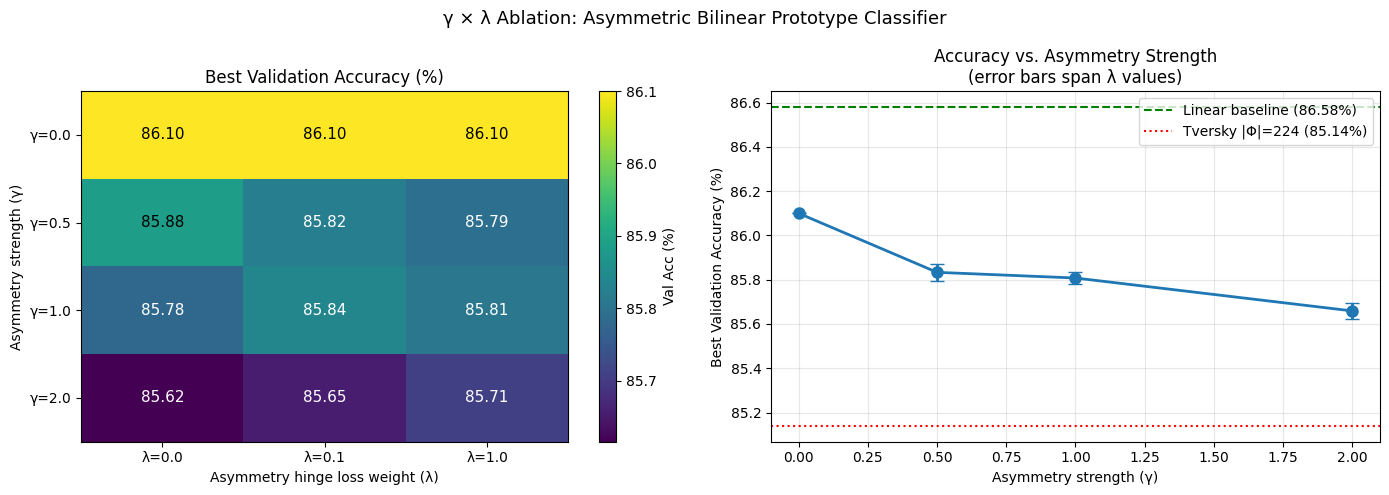

Saved heatmap to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/results/ablation_gamma_lambda_heatmap.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Build the accuracy matrix
acc_matrix = np.zeros((len(GAMMA_VALUES), len(LAMBDA_VALUES)))
for i, gamma in enumerate(GAMMA_VALUES):
    for j, lam in enumerate(LAMBDA_VALUES):
        acc_matrix[i, j] = ablation_results[(gamma, lam)]["best_val_acc"] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: heatmap
im = ax1.imshow(acc_matrix, cmap="viridis", aspect="auto")
ax1.set_xticks(range(len(LAMBDA_VALUES)))
ax1.set_xticklabels([f"λ={l}" for l in LAMBDA_VALUES])
ax1.set_yticks(range(len(GAMMA_VALUES)))
ax1.set_yticklabels([f"γ={g}" for g in GAMMA_VALUES])
ax1.set_xlabel("Asymmetry hinge loss weight (λ)")
ax1.set_ylabel("Asymmetry strength (γ)")
ax1.set_title("Best Validation Accuracy (%)")

# Annotate each cell
for i in range(len(GAMMA_VALUES)):
    for j in range(len(LAMBDA_VALUES)):
        ax1.text(j, i, f"{acc_matrix[i, j]:.2f}",
                 ha="center", va="center",
                 color="white" if acc_matrix[i, j] < acc_matrix.mean() else "black",
                 fontsize=11)
plt.colorbar(im, ax=ax1, label="Val Acc (%)")

# Right: accuracy vs gamma (averaged over lambda, since lambda barely matters)
gamma_means = acc_matrix.mean(axis=1)
gamma_stds = acc_matrix.std(axis=1)
ax2.errorbar(GAMMA_VALUES, gamma_means, yerr=gamma_stds, marker="o",
             markersize=8, capsize=5, linewidth=2, color="C0")
ax2.axhline(86.58, color="green", linestyle="--", label="Linear baseline (86.58%)")
ax2.axhline(85.14, color="red", linestyle=":", label="Tversky |Φ|=224 (85.14%)")
ax2.set_xlabel("Asymmetry strength (γ)")
ax2.set_ylabel("Best Validation Accuracy (%)")
ax2.set_title("Accuracy vs. Asymmetry Strength\n(error bars span λ values)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("γ × λ Ablation: Asymmetric Bilinear Prototype Classifier", fontsize=13)
plt.tight_layout()

plot_path = RESULTS_DIR / "ablation_gamma_lambda_heatmap.png"
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()

print(f"Saved heatmap to {plot_path}")

In [8]:
# Regularization sweep: does stronger weight decay change the asymmetry penalty?
GAMMA_SWEEP = [0.0, 2.0]
WD_SWEEP = [1e-4, 1e-3, 1e-2, 1e-1]
LAMBDA_FIXED = 0.0
MARGIN = 0.1
N_EPOCHS = 20
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss()
reg_results = {}

total = len(GAMMA_SWEEP) * len(WD_SWEEP)
config_num = 0
grand_start = time.time()

print(f"Regularization sweep: γ ∈ {GAMMA_SWEEP}, weight_decay ∈ {WD_SWEEP}")
print(f"  λ = {LAMBDA_FIXED} (fixed), {N_EPOCHS} epochs each\n")
print(f"{'Config':>7} | {'γ':>4} | {'WD':>7} | {'Best Val':>9} | {'@Ep':>4} | "
      f"{'Final Train':>11} | {'Train-Val Gap':>13} | {'Time':>6}")
print("-" * 90)

for gamma in GAMMA_SWEEP:
    for wd in WD_SWEEP:
        config_num += 1
        config_start = time.time()
        
        torch.manual_seed(42)
        model = AsymmetricBilinearClassifier(embed_dim=2048, n_classes=100, gamma=gamma).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=wd)
        
        history = {"train_acc": [], "val_acc": []}
        for epoch in range(1, N_EPOCHS + 1):
            tm = train_one_epoch_asym(model, train_loader, optimizer, criterion, device, LAMBDA_FIXED, MARGIN)
            val_loss, val_acc = evaluate_asym(model, val_loader, criterion, device)
            history["train_acc"].append(tm["acc"])
            history["val_acc"].append(val_acc)
        
        best_val = max(history["val_acc"])
        best_epoch = history["val_acc"].index(best_val) + 1
        final_train = history["train_acc"][-1]
        # Gap measured at the best-val epoch
        gap = history["train_acc"][best_epoch - 1] - best_val
        config_time = time.time() - config_start
        
        reg_results[(gamma, wd)] = {
            "history": history,
            "best_val_acc": best_val,
            "best_val_epoch": best_epoch,
            "final_train_acc": final_train,
            "gap_at_best": gap,
        }
        
        print(f"{config_num:>3}/{total} | {gamma:>4.1f} | {wd:>7.0e} | "
              f"{best_val:>8.2%} | {best_epoch:>4} | {final_train:>10.2%} | "
              f"{gap:>12.2%} | {config_time:>5.0f}s")

print("-" * 90)
print(f"Total time: {(time.time() - grand_start)/60:.1f} minutes")

# Print the key comparison: gap between gamma=0 and gamma=2 at each WD
print(f"\n{'Weight Decay':>12} | {'γ=0 Val':>8} | {'γ=2 Val':>8} | {'Asymmetry Penalty':>18}")
print("-" * 56)
for wd in WD_SWEEP:
    v0 = reg_results[(0.0, wd)]["best_val_acc"]
    v2 = reg_results[(2.0, wd)]["best_val_acc"]
    penalty = (v0 - v2) * 100
    print(f"{wd:>12.0e} | {v0:>7.2%} | {v2:>7.2%} | {penalty:>+17.3f} pts")

Regularization sweep: γ ∈ [0.0, 2.0], weight_decay ∈ [0.0001, 0.001, 0.01, 0.1]
  λ = 0.0 (fixed), 20 epochs each

 Config |    γ |      WD |  Best Val |  @Ep | Final Train | Train-Val Gap |   Time
------------------------------------------------------------------------------------------
  1/8 |  0.0 |   1e-04 |   86.10% |   15 |     91.83% |        5.24% |   182s
  2/8 |  0.0 |   1e-03 |   84.90% |   12 |     85.54% |        0.56% |   195s
  3/8 |  0.0 |   1e-02 |   78.98% |    2 |     76.88% |        0.89% |   202s
  4/8 |  0.0 |   1e-01 |   64.42% |    1 |      1.44% |       -1.47% |   206s
  5/8 |  2.0 |   1e-04 |   85.62% |    2 |     90.89% |        1.36% |   212s
  6/8 |  2.0 |   1e-03 |   84.58% |   16 |     86.11% |        1.29% |   216s
  7/8 |  2.0 |   1e-02 |   79.95% |   12 |     80.02% |       -0.06% |   217s
  8/8 |  2.0 |   1e-01 |   55.61% |    1 |      8.75% |        3.30% |   219s
---------------------------------------------------------------------------------------

In [9]:
import pickle

reg_path = RESULTS_DIR / "regularization_sweep.pkl"
with open(reg_path, "wb") as f:
    pickle.dump({
        "results": reg_results,
        "config": {
            "gamma_sweep": GAMMA_SWEEP,
            "wd_sweep": WD_SWEEP,
            "lambda_fixed": LAMBDA_FIXED,
            "margin": MARGIN,
            "n_epochs": N_EPOCHS,
            "learning_rate": LEARNING_RATE,
            "seed": 42,
        },
    }, f)

# JSON summary
reg_summary = {}
for (gamma, wd), res in reg_results.items():
    reg_summary[f"gamma{gamma}_wd{wd:.0e}"] = {
        "gamma": gamma,
        "weight_decay": wd,
        "best_val_acc": res["best_val_acc"],
        "best_val_epoch": res["best_val_epoch"],
        "final_train_acc": res["final_train_acc"],
        "gap_at_best": res["gap_at_best"],
    }

with open(RESULTS_DIR / "regularization_summary.json", "w") as f:
    json.dump(reg_summary, f, indent=2)

print(f"Saved to {reg_path}")

Saved to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/results/regularization_sweep.pkl


In [8]:
class LinearClassifier(nn.Module):
    def __init__(self, embed_dim=2048, n_classes=100):
        super().__init__()
        self.fc = nn.Linear(embed_dim, n_classes)
    def forward(self, x):
        return self.fc(x)


class CosinePrototypeClassifier(nn.Module):
    def __init__(self, embed_dim=2048, n_classes=100, init_temperature=10.0):
        super().__init__()
        self.prototypes = nn.Parameter(torch.randn(n_classes, embed_dim))
        self.temperature = nn.Parameter(torch.tensor(float(init_temperature)))
    def forward(self, x):
        x_norm = F.normalize(x, p=2, dim=1)
        proto_norm = F.normalize(self.prototypes, p=2, dim=1)
        return self.temperature * (x_norm @ proto_norm.T)


class TverskyProjectionLayer(nn.Module):
    def __init__(self, embed_dim=2048, n_classes=100, n_features=224):
        super().__init__()
        self.embed_dim = embed_dim
        self.n_classes = n_classes
        self.n_features = n_features
        self.feature_bank = nn.Parameter(torch.empty(n_features, embed_dim))
        nn.init.uniform_(self.feature_bank, -0.1, 0.1)
        self.prototypes = nn.Parameter(torch.empty(n_classes, embed_dim))
        nn.init.uniform_(self.prototypes, -0.1, 0.1)
        self.epsilon = nn.Parameter(torch.tensor(1.0))
        self.theta = nn.Parameter(torch.tensor(1.0))
        self.omega = nn.Parameter(torch.tensor(1.0))
    def forward(self, x):
        B, F_n, C = x.size(0), self.n_features, self.n_classes
        X = x @ self.feature_bank.T
        Y = self.prototypes @ self.feature_bank.T
        X_active = (X > 0).float()
        Y_active = (Y > 0).float()
        X_bcf = X.unsqueeze(1).expand(B, C, F_n)
        Y_bcf = Y.unsqueeze(0).expand(B, C, F_n)
        X_act = X_active.unsqueeze(1).expand(B, C, F_n)
        Y_act = Y_active.unsqueeze(0).expand(B, C, F_n)
        both = X_act * Y_act
        f_intersect = (X_bcf * Y_bcf * both).sum(dim=2)
        only_X = X_act * (1 - Y_act)
        f_X = (X_bcf * only_X).sum(dim=2) + ((X_bcf - Y_bcf) * (both * (X_bcf > Y_bcf).float())).sum(dim=2)
        only_Y = Y_act * (1 - X_act)
        f_Y = (Y_bcf * only_Y).sum(dim=2) + ((Y_bcf - X_bcf) * (both * (Y_bcf > X_bcf).float())).sum(dim=2)
        return self.omega * f_intersect - self.epsilon * f_X - self.theta * f_Y


print("All model classes defined.")

All model classes defined.


In [11]:
heldout_features, heldout_labels = load_embeddings("heldout")
heldout_dataset = TensorDataset(heldout_features, heldout_labels)
heldout_loader = DataLoader(heldout_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Held-out: {len(heldout_features):,} samples, {len(heldout_loader)} batches")

Held-out: 5,000 samples, 10 batches


In [15]:
def build_model(name, device):
    """Factory: instantiate a fresh model by name."""
    if name == "linear":
        return LinearClassifier(2048, 100).to(device)
    elif name == "cosine":
        return CosinePrototypeClassifier(2048, 100, init_temperature=10.0).to(device)
    elif name == "symmetric":
        return AsymmetricBilinearClassifier(2048, 100, gamma=0.0).to(device)
    elif name == "asymmetric":
        return AsymmetricBilinearClassifier(2048, 100, gamma=1.0).to(device)
    elif name == "tversky":
        return TverskyProjectionLayer(2048, 100, n_features=224).to(device)
    else:
        raise ValueError(name)


@torch.no_grad()
def eval_acc(model, loader, device):
    model.eval()
    correct = total = 0
    for f, l in loader:
        f, l = f.to(device), l.to(device)
        correct += (model(f).argmax(dim=1) == l).sum().item()
        total += f.size(0)
    return correct / total


def train_and_eval(name, seed, n_epochs, device):
    """
    Train one model with one seed. Track val + held-out acc per epoch.
    Return held-out acc at the epoch where val acc was highest.
    """
    torch.manual_seed(seed)
    model = build_model(name, device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    val_accs, heldout_accs = [], []
    for epoch in range(1, n_epochs + 1):
        # one training pass
        model.train()
        for f, l in train_loader:
            f, l = f.to(device), l.to(device)
            loss = criterion(model(f), l)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        val_accs.append(eval_acc(model, val_loader, device))
        heldout_accs.append(eval_acc(model, heldout_loader, device))
    
    # Select epoch by best VALIDATION accuracy, report HELD-OUT at that epoch
    best_val_epoch = val_accs.index(max(val_accs))
    return {
        "best_val_acc": val_accs[best_val_epoch],
        "heldout_at_best_val": heldout_accs[best_val_epoch],
        "best_val_epoch": best_val_epoch + 1,
        "val_accs": val_accs,
        "heldout_accs": heldout_accs,
    }


# Run the full evaluation
MODELS = ["linear", "cosine", "symmetric", "asymmetric", "tversky"]
SEEDS = [42, 123, 7]
N_EPOCHS = 20

heldout_eval = {}
grand_start = time.time()

print(f"Multi-seed held-out evaluation")
print(f"  Models: {MODELS}")
print(f"  Seeds: {SEEDS}, {N_EPOCHS} epochs each\n")
print(f"{'Model':>12} | {'Seed':>5} | {'Val (sel)':>9} | {'Held-out':>9} | {'@Ep':>4} | {'Time':>6}")
print("-" * 70)

for name in MODELS:
    heldout_eval[name] = []
    for seed in SEEDS:
        t0 = time.time()
        res = train_and_eval(name, seed, N_EPOCHS, device)
        heldout_eval[name].append(res)
        print(f"{name:>12} | {seed:>5} | {res['best_val_acc']:>8.2%} | "
              f"{res['heldout_at_best_val']:>8.2%} | {res['best_val_epoch']:>4} | "
              f"{time.time()-t0:>5.0f}s")

print("-" * 70)
print(f"Total: {(time.time()-grand_start)/60:.1f} min")

Multi-seed held-out evaluation
  Models: ['linear', 'cosine', 'symmetric', 'asymmetric', 'tversky']
  Seeds: [42, 123, 7], 20 epochs each

       Model |  Seed | Val (sel) |  Held-out |  @Ep |   Time
----------------------------------------------------------------------
      linear |    42 |   86.48% |   84.44% |   20 |    15s
      linear |   123 |   86.46% |   84.40% |   17 |    14s
      linear |     7 |   86.47% |   84.38% |   17 |    15s
      cosine |    42 |   83.58% |   81.10% |   20 |    20s
      cosine |   123 |   83.48% |   80.92% |   20 |    21s
      cosine |     7 |   83.48% |   80.86% |   20 |    21s
   symmetric |    42 |   86.21% |   84.08% |   16 |    90s
   symmetric |   123 |   86.13% |   83.34% |   10 |    90s
   symmetric |     7 |   86.02% |   83.44% |   14 |    90s
  asymmetric |    42 |   85.55% |   83.30% |   19 |    90s
  asymmetric |   123 |   85.52% |   82.86% |   14 |    90s
  asymmetric |     7 |   85.68% |   83.14% |    7 |    90s
     tversky |    42 

In [ ]:
import numpy as np

print(f"{'Model':>12} | {'Held-out (mean ± std)':>22} | {'Val (mean)':>11} | {'Range':>14}")
print("-" * 70)

summary_stats = {}
for name in MODELS:
    heldouts = [r["heldout_at_best_val"] for r in heldout_eval[name]]
    vals = [r["best_val_acc"] for r in heldout_eval[name]]
    mean_h = np.mean(heldouts) * 100
    std_h = np.std(heldouts) * 100
    mean_v = np.mean(vals) * 100
    summary_stats[name] = {
        "heldout_mean": mean_h, "heldout_std": std_h,
        "val_mean": mean_v,
        "heldout_runs": [h * 100 for h in heldouts],
    }
    print(f"{name:>12} | {mean_h:>10.2f} ± {std_h:>4.2f}%       | "
          f"{mean_v:>10.2f}% | [{min(heldouts)*100:.2f}, {max(heldouts)*100:.2f}]")

# Save everything
with open(RESULTS_DIR / "heldout_evaluation.pkl", "wb") as f:
    pickle.dump({"raw": heldout_eval, "summary": summary_stats,
                 "models": MODELS, "seeds": SEEDS, "n_epochs": N_EPOCHS}, f)
print(f"\nSaved to {RESULTS_DIR / 'heldout_evaluation.pkl'}")

       Model |  Held-out (mean ± std) |  Val (mean) |          Range
----------------------------------------------------------------------
      linear |      84.41 ± 0.02%       |      86.47% | [84.38, 84.44]
      cosine |      80.96 ± 0.10%       |      83.52% | [80.86, 81.10]
   symmetric |      83.62 ± 0.33%       |      86.12% | [83.34, 84.08]
  asymmetric |      83.10 ± 0.18%       |      85.58% | [82.86, 83.30]
     tversky |      82.35 ± 0.25%       |      85.10% | [82.02, 82.62]

Saved to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/results/heldout_evaluation.pkl


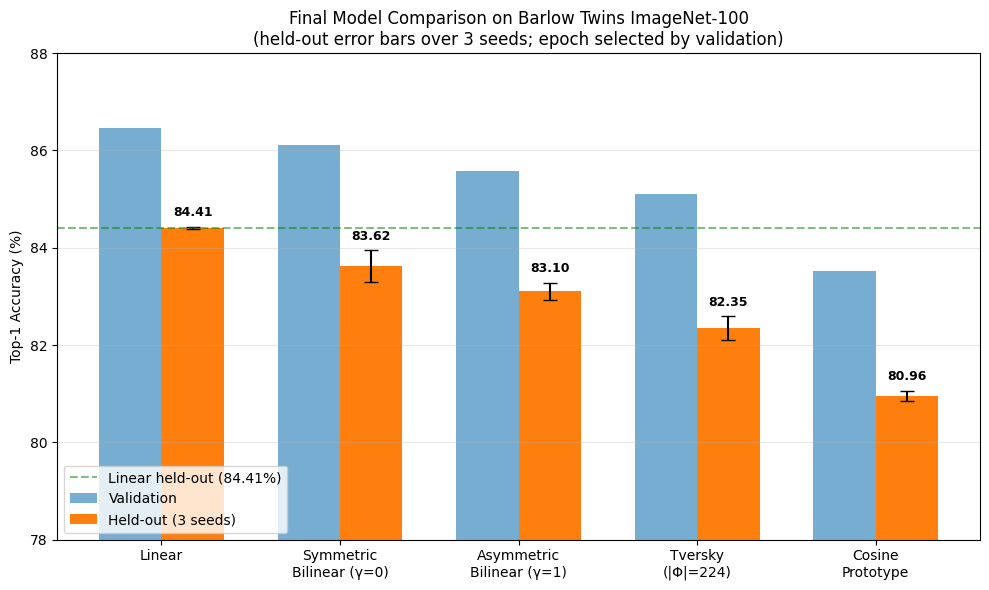

Saved final comparison to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/results/final_comparison.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Order models from best to worst on held-out
model_order = ["linear", "symmetric", "asymmetric", "tversky", "cosine"]
display_names = {
    "linear": "Linear",
    "symmetric": "Symmetric\nBilinear (γ=0)",
    "asymmetric": "Asymmetric\nBilinear (γ=1)",
    "tversky": "Tversky\n(|Φ|=224)",
    "cosine": "Cosine\nPrototype",
}

heldout_means = [summary_stats[m]["heldout_mean"] for m in model_order]
heldout_stds = [summary_stats[m]["heldout_std"] for m in model_order]
val_means = [summary_stats[m]["val_mean"] for m in model_order]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(model_order))
width = 0.35

bars1 = ax.bar(x - width/2, val_means, width, label="Validation",
               color="C0", alpha=0.6)
bars2 = ax.bar(x + width/2, heldout_means, width, yerr=heldout_stds,
               label="Held-out (3 seeds)", color="C1", capsize=5)

# Annotate held-out values
for i, (m, s) in enumerate(zip(heldout_means, heldout_stds)):
    ax.text(i + width/2, m + s + 0.15, f"{m:.2f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(heldout_means[0], color="green", linestyle="--", alpha=0.5,
           label=f"Linear held-out ({heldout_means[0]:.2f}%)")

ax.set_xticks(x)
ax.set_xticklabels([display_names[m] for m in model_order])
ax.set_ylabel("Top-1 Accuracy (%)")
ax.set_title("Final Model Comparison on Barlow Twins ImageNet-100\n"
             "(held-out error bars over 3 seeds; epoch selected by validation)")
ax.legend(loc="lower left")
ax.set_ylim(78, 88)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plot_path = RESULTS_DIR / "final_comparison.png"
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()

print(f"Saved final comparison to {plot_path}")